<a href="https://colab.research.google.com/github/Yovana-Palencia/Mineria-De-Datos/blob/main/LigaMX_jornada17.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Predicción de resultados Liga MX jornada 17

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

In [2]:
#Dataset jornadas 13, 14, 15
df_original = pd.read_csv('dataset_liga_mx_jornadas_13_14_15_base.csv')
print(f'Registros originales (J13-J15): {len(df_original)}')
df_original.head(10)

Registros originales (J13-J15): 9


,jornada,equipo_local,equipo_visita,resultado,local_puntos,visita_puntos,local_racha,visita_racha,local_posicion,visita_posicion,diff_puntos,diff_racha,diff_posicion
0,15,Mazatlán,Querétaro,1,12,16,2,4,17,13,-4,-2,-4
1,15,Atlético San Luis,Pumas,0,15,30,6,7,15,3,-15,-1,-12
2,15,Necaxa,Tigres,1,17,21,5,4,11,9,-4,1,-2
3,15,Cruz Azul,Tijuana,1,29,19,5,4,4,10,10,1,6
4,15,Monterrey,Pachuca,0,15,31,1,9,14,2,-16,-8,-12
5,15,Chivas,Puebla,2,34,13,9,0,1,16,21,9,15
6,15,León,FC Juárez,2,22,16,9,1,8,12,6,8,4
7,15,América,Toluca,2,22,27,6,5,6,5,-5,1,-1
8,15,Santos,Atlas,0,9,22,0,7,18,7,-13,-7,-11


In [3]:
#DATOS DE LA JORNADA 16
#Resultados reales: 1=Empate, 2=Local, 0=Visita

data_j16 = {
    'jornada':         [16,   16,   16,   16,   16,   16,   16,   16,   16],
    'equipo_local':    ['Querétaro', 'Pumas', 'Monterrey', 'León',
                        'Atlas', 'Atlético San Luis', 'Mazatlán',
                        'Necaxa', 'Tijuana'],
    'equipo_visita':   ['Cruz Azul', 'FC Juárez', 'Puebla', 'América',
                        'Tigres', 'Santos', 'Toluca',
                        'Chivas', 'Pachuca'],
    #Resultado real: 1=Empate, 2=Local, 0=Visita
    'resultado':       [1,    2,    2,    0,    1,    2,    2,    1,    2],
    #Puntos antes de J16
    'local_puntos':    [16,   30,   18,   22,   23,   16,   11,   17,   19],
    'visita_puntos':   [29,   16,   12,   22,   22,    9,   27,   34,   31],
    #Racha antes de J16 (positivo=victorias consecutivas, negativo=sin ganar)
    'local_racha':     [ 1,    7,    2,    4,    3,    1,    1,    5,    4],
    'visita_racha':    [ 0,    1,    0,    6,    4,    0,    0,   11,    9],
    #Posición antes de J16
    'local_posicion':  [14,    2,   11,    7,    8,   12,   16,   13,   10],
    'visita_posicion': [ 4,   15,   17,    6,    9,   18,    5,    1,    3],
}

df_j16 = pd.DataFrame(data_j16)

#Calcular diferencias (local - visita)
df_j16['diff_puntos']   = df_j16['local_puntos']   - df_j16['visita_puntos']
df_j16['diff_racha']    = df_j16['local_racha']    - df_j16['visita_racha']
df_j16['diff_posicion'] = df_j16['visita_posicion'] - df_j16['local_posicion']  # invertido: mayor diff = local mejor posicionado

print('Datos Jornada 16:')
df_j16

Datos Jornada 16:


,jornada,equipo_local,equipo_visita,resultado,local_puntos,visita_puntos,local_racha,visita_racha,local_posicion,visita_posicion,diff_puntos,diff_racha,diff_posicion
0,16,Querétaro,Cruz Azul,1,16,29,1,0,14,4,-13,1,-10
1,16,Pumas,FC Juárez,2,30,16,7,1,2,15,14,6,13
2,16,Monterrey,Puebla,2,18,12,2,0,11,17,6,2,6
3,16,León,América,0,22,22,4,6,7,6,0,-2,-1
4,16,Atlas,Tigres,1,23,22,3,4,8,9,1,-1,1
5,16,Atlético San Luis,Santos,2,16,9,1,0,12,18,7,1,6
6,16,Mazatlán,Toluca,2,11,27,1,0,16,5,-16,1,-11
7,16,Necaxa,Chivas,1,17,34,5,11,13,1,-17,-6,-12
8,16,Tijuana,Pachuca,2,19,31,4,9,10,3,-12,-5,-7


In [4]:
#Unir datasets J13-J15 + J16
df_completo = pd.concat([df_original, df_j16], ignore_index=True)
print(f'Total de registros en el dataset actualizado: {len(df_completo)}')
print(f'Distribución de resultados:')
print(df_completo['resultado'].value_counts().rename({0:'Visita gana', 1:'Empate', 2:'Local gana'}))
df_completo.tail(10)

Total de registros en el dataset actualizado: 18
Distribución de resultados:
resultado
Local gana     8
Empate         6
Visita gana    4
Name: count, dtype: int64


,jornada,equipo_local,equipo_visita,resultado,local_puntos,visita_puntos,local_racha,visita_racha,local_posicion,visita_posicion,diff_puntos,diff_racha,diff_posicion
8,15,Santos,Atlas,0,9,22,0,7,18,7,-13,-7,-11
9,16,Querétaro,Cruz Azul,1,16,29,1,0,14,4,-13,1,-10
10,16,Pumas,FC Juárez,2,30,16,7,1,2,15,14,6,13
11,16,Monterrey,Puebla,2,18,12,2,0,11,17,6,2,6
12,16,León,América,0,22,22,4,6,7,6,0,-2,-1
13,16,Atlas,Tigres,1,23,22,3,4,8,9,1,-1,1
14,16,Atlético San Luis,Santos,2,16,9,1,0,12,18,7,1,6
15,16,Mazatlán,Toluca,2,11,27,1,0,16,5,-16,1,-11
16,16,Necaxa,Chivas,1,17,34,5,11,13,1,-17,-6,-12
17,16,Tijuana,Pachuca,2,19,31,4,9,10,3,-12,-5,-7


In [5]:
#Selección de features
features = ['diff_puntos', 'diff_racha', 'diff_posicion']
X = df_completo[features]
y = df_completo['resultado']

#Entrenamiento del Random Forest (mismo config que J16)
rf = RandomForestClassifier(n_estimators=300, max_depth=5, random_state=42)
rf.fit(X, y)

print('Modelo entrenado con datos de J13 a J16')
print(f'   Clases: {rf.classes_}  → 0=Visita, 1=Empate, 2=Local')

Modelo entrenado con datos de J13 a J16
   Clases: [0 1 2]  → 0=Visita, 1=Empate, 2=Local


Importancia de cada variable:
diff_puntos      0.364823
diff_racha       0.339543
diff_posicion    0.295634
dtype: float64


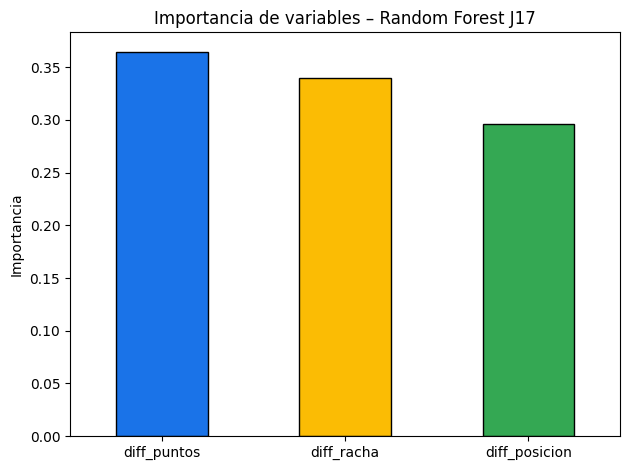

In [6]:
#Importancia de variables
importancias = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
print('Importancia de cada variable:')
print(importancias)

importancias.plot(kind='bar', color=['#1a73e8','#fbbc04','#34a853'], edgecolor='black')
plt.title('Importancia de variables – Random Forest J17')
plt.ylabel('Importancia')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [7]:
# PARTIDO 1: Puebla vs Querétaro

partido1 = pd.DataFrame([[0, -1, -3]], columns=features)
pred1 = rf.predict(partido1)[0]
prob1 = rf.predict_proba(partido1)[0]
res_map = {2: 'Victoria Local', 1: 'Empate', 0: 'Victoria Visita'}

print('─'*55)
print('PARTIDO 1 │ Puebla (L) vs Querétaro (V)')
print(f'  Pronóstico : {res_map[pred1]}')
print(f'  Probs      : Puebla={prob1[2]:.1%} │ Empate={prob1[1]:.1%} │ Querétaro={prob1[0]:.1%}')

───────────────────────────────────────────────────────
PARTIDO 1 │ Puebla (L) vs Querétaro (V)
  Pronóstico : Empate
  Probs      : Puebla=3.3% │ Empate=71.1% │ Querétaro=25.6%


In [8]:
# PARTIDO 2: Pachuca vs Pumas

partido2 = pd.DataFrame([[-2, -9, -1]], columns=features)
pred2 = rf.predict(partido2)[0]
prob2 = rf.predict_proba(partido2)[0]

print('─'*55)
print('PARTIDO 2 │ Pachuca (L) vs Pumas (V)')
print(f'  Pronóstico : {res_map[pred2]}')
print(f'  Probs      : Pachuca={prob2[2]:.1%} │ Empate={prob2[1]:.1%} │ Pumas={prob2[0]:.1%}')

───────────────────────────────────────────────────────
PARTIDO 2 │ Pachuca (L) vs Pumas (V)
  Pronóstico : Victoria Visita
  Probs      : Pachuca=14.8% │ Empate=30.2% │ Pumas=55.0%


In [9]:
# PARTIDO 3: Tigres vs Mazatlán

partido3 = pd.DataFrame([[7, -4, 8]], columns=features)
pred3 = rf.predict(partido3)[0]
prob3 = rf.predict_proba(partido3)[0]

print('─'*55)
print('PARTIDO 3 │ Tigres (L) vs Mazatlán (V)')
print(f'  Pronóstico : {res_map[pred3]}')
print(f'  Probs      : Tigres={prob3[2]:.1%} │ Empate={prob3[1]:.1%} │ Mazatlán={prob3[0]:.1%}')

───────────────────────────────────────────────────────
PARTIDO 3 │ Tigres (L) vs Mazatlán (V)
  Pronóstico : Victoria Local
  Probs      : Tigres=57.8% │ Empate=25.1% │ Mazatlán=17.1%


In [10]:
# PARTIDO 4: Toluca vs León

partido4 = pd.DataFrame([[5, 0, 5]], columns=features)
pred4 = rf.predict(partido4)[0]
prob4 = rf.predict_proba(partido4)[0]

print('─'*55)
print('PARTIDO 4 │ Toluca (L) vs León (V)')
print(f'  Pronóstico : {res_map[pred4]}')
print(f'  Probs      : Toluca={prob4[2]:.1%} │ Empate={prob4[1]:.1%} │ León={prob4[0]:.1%}')

───────────────────────────────────────────────────────
PARTIDO 4 │ Toluca (L) vs León (V)
  Pronóstico : Victoria Local
  Probs      : Toluca=53.8% │ Empate=37.9% │ León=8.3%


In [11]:
# PARTIDO 5: Chivas vs Tijuana

partido5 = pd.DataFrame([[13, -3, 8]], columns=features)
pred5 = rf.predict(partido5)[0]
prob5 = rf.predict_proba(partido5)[0]

print('─'*55)
print('PARTIDO 5 │ Chivas (L) vs Tijuana (V)')
print(f'  Pronóstico : {res_map[pred5]}')
print(f'  Probs      : Chivas={prob5[2]:.1%} │ Empate={prob5[1]:.1%} │ Tijuana={prob5[0]:.1%}')

───────────────────────────────────────────────────────
PARTIDO 5 │ Chivas (L) vs Tijuana (V)
  Pronóstico : Empate
  Probs      : Chivas=30.4% │ Empate=50.6% │ Tijuana=19.0%


In [12]:
# PARTIDO 6: América vs Atlas

partido6 = pd.DataFrame([[2, 2, 1]], columns=features)
pred6 = rf.predict(partido6)[0]
prob6 = rf.predict_proba(partido6)[0]

print('─'*55)
print('PARTIDO 6 │ América (L) vs Atlas (V)')
print(f'  Pronóstico : {res_map[pred6]}')
print(f'  Probs      : América={prob6[2]:.1%} │ Empate={prob6[1]:.1%} │ Atlas={prob6[0]:.1%}')

───────────────────────────────────────────────────────
PARTIDO 6 │ América (L) vs Atlas (V)
  Pronóstico : Victoria Local
  Probs      : América=54.7% │ Empate=37.1% │ Atlas=8.2%


In [13]:
# PARTIDO 7: FC Juárez vs Atlético San Luis

partido7 = pd.DataFrame([[-2, -4, -3]], columns=features)
pred7 = rf.predict(partido7)[0]
prob7 = rf.predict_proba(partido7)[0]

print('─'*55)
print('PARTIDO 7 │ FC Juárez (L) vs Atlético San Luis (V)')
print(f'  Pronóstico : {res_map[pred7]}')
print(f'  Probs      : FC Juárez={prob7[2]:.1%} │ Empate={prob7[1]:.1%} │ Atl. SL={prob7[0]:.1%}')

───────────────────────────────────────────────────────
PARTIDO 7 │ FC Juárez (L) vs Atlético San Luis (V)
  Pronóstico : Empate
  Probs      : FC Juárez=23.7% │ Empate=61.0% │ Atl. SL=15.3%


In [14]:
# PARTIDO 8: Santos vs Monterrey

partido8 = pd.DataFrame([[-9, -3, -7]], columns=features)
pred8 = rf.predict(partido8)[0]
prob8 = rf.predict_proba(partido8)[0]

print('─'*55)
print('PARTIDO 8 │ Santos (L) vs Monterrey (V)')
print(f'  Pronóstico : {res_map[pred8]}')
print(f'  Probs      : Santos={prob8[2]:.1%} │ Empate={prob8[1]:.1%} │ Monterrey={prob8[0]:.1%}')

───────────────────────────────────────────────────────
PARTIDO 8 │ Santos (L) vs Monterrey (V)
  Pronóstico : Victoria Local
  Probs      : Santos=46.9% │ Empate=38.7% │ Monterrey=14.4%


In [15]:
# PARTIDO 9: Cruz Azul vs Necaxa

partido9 = pd.DataFrame([[12, -6, 9]], columns=features)
pred9 = rf.predict(partido9)[0]
prob9 = rf.predict_proba(partido9)[0]

print('─'*55)
print('PARTIDO 9 │ Cruz Azul (L) vs Necaxa (V)')
print(f'  Pronóstico : {res_map[pred9]}')
print(f'  Probs      : Cruz Azul={prob9[2]:.1%} │ Empate={prob9[1]:.1%} │ Necaxa={prob9[0]:.1%}')

───────────────────────────────────────────────────────
PARTIDO 9 │ Cruz Azul (L) vs Necaxa (V)
  Pronóstico : Empate
  Probs      : Cruz Azul=31.0% │ Empate=49.3% │ Necaxa=19.7%


In [16]:
# ─── Tabla resumen completa ────────────────────────────────
data_j17 = {
    'Partido': [
        'Puebla vs Querétaro',
        'Pachuca vs Pumas',
        'Tigres vs Mazatlán',
        'Toluca vs León',
        'Chivas vs Tijuana',
        'América vs Atlas',
        'FC Juárez vs Atl. San Luis',
        'Santos vs Monterrey',
        'Cruz Azul vs Necaxa'
    ],
    'diff_puntos':   [0,  -2,  7,  5, 13,  2, -2,  -9, 12],
    'diff_racha':    [-1, -9, -4,  0, -3,  2, -4,  -3, -6],
    'diff_posicion': [-3, -1,  8,  5,  8,  1, -3,  -7,  9],
}

df_j17 = pd.DataFrame(data_j17)

# Predicciones batch
X_j17 = df_j17[['diff_puntos', 'diff_racha', 'diff_posicion']]
df_j17['Cod_Pred'] = rf.predict(X_j17)
df_j17['Pronóstico'] = df_j17['Cod_Pred'].map({2:'Local', 1:'Empate', 0:'Visita'})

# Probabilidades
probs = rf.predict_proba(X_j17)
df_j17['P(Local)']  = [f'{p[2]:.0%}' for p in probs]
df_j17['P(Empate)'] = [f'{p[1]:.0%}' for p in probs]
df_j17['P(Visita)'] = [f'{p[0]:.0%}' for p in probs]

print('═'*75)
print('        PREDICCIONES LIGA MX – JORNADA 17 (Clausura 2026)')
print('═'*75)
print(df_j17[['Partido','Pronóstico','P(Local)','P(Empate)','P(Visita)']].to_string(index=False))
print('═'*75)

═══════════════════════════════════════════════════════════════════════════
        PREDICCIONES LIGA MX – JORNADA 17 (Clausura 2026)
═══════════════════════════════════════════════════════════════════════════
                   Partido Pronóstico P(Local) P(Empate) P(Visita)
       Puebla vs Querétaro     Empate       3%       71%       26%
          Pachuca vs Pumas     Visita      15%       30%       55%
        Tigres vs Mazatlán      Local      58%       25%       17%
            Toluca vs León      Local      54%       38%        8%
         Chivas vs Tijuana     Empate      30%       51%       19%
          América vs Atlas      Local      55%       37%        8%
FC Juárez vs Atl. San Luis     Empate      24%       61%       15%
       Santos vs Monterrey      Local      47%       39%       14%
       Cruz Azul vs Necaxa     Empate      31%       49%       20%
═══════════════════════════════════════════════════════════════════════════
